# E-Commerce Purchase Prediction — Neural Network with PyTorch

## Business Problem

**ShopSmart** is a fast-growing international e-commerce platform operating across Europe, North America and Asia. They sell Fashion, Electronics and Home Goods.

The marketing team wants to answer one question:

> **"Which customers are most likely to make a purchase based on their browsing behaviour?"**

By predicting purchase intent, ShopSmart can:
- Show targeted promotions only to likely buyers
- Reduce wasted marketing spend
- Increase conversion rate and revenue

---
`

---

## Dataset Description

| Column | Type | Description |
|---|---|---|
| customer_id | Integer | Unique identifier |
| age | Integer | Customer age |
| time_spent | Float | Minutes on website per session |
| pages_viewed | Integer | Pages viewed per session |
| basket_value | Float | Value of items in basket |
| device_type | String | Mobile, Desktop, Tablet |
| customer_type | String | New, Returning |
| category | String | Fashion, Electronics, Home Goods |
| num_sessions | Integer | Number of sessions |
| purchase | Binary | 1 = bought, 0 = did not buy |

---

## Step 0 — Import Libraries

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
from matplotlib.patches import Patch
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Reproducibility
np.random.seed(42)
torch.manual_seed(42)

print('All libraries imported successfully')

All libraries imported successfully


---

## Step 1 — Load and Inspect Raw Data

Before touching any data, a data scientist always inspects it first.
We want to understand:
- How many rows and columns
- What data types each column has
- How many missing values exist
- What the data looks like

In [ ]:
df = pd.read_csv('../data/raw_customer_data.csv')

print('=== Shape (rows, columns) ===')
print(df.shape)

print('\n=== First 5 rows ===')
print(df.head())

print('\n=== Data types and non-null counts ===')
print(df.info())

=== Shape (rows, columns) ===
(5000, 10)

=== First 5 rows ===
   customer_id  age  time_spent  pages_viewed  basket_value device_type  \
0            1   56       94.80          16.0         59.43      Mobile   
1            2   69       15.28          20.0         20.80     Desktop   
2            3   46       54.94          29.0         10.37      Mobile   
3            4   32        6.27           6.0         36.13      Mobile   
4            5   60       33.48          26.0         23.60      Mobile   

  customer_type     category  num_sessions  purchase  
0     Returning      Fashion            16         1  
1     Returning  Electronics            11         0  
2     Returning  Electronics             4         0  
3     Returning   Home Goods             9         1  
4     Returning      Fashion            15         1  

=== Data types and non-null counts ===
<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 10 columns):
 #   Column         

In [3]:
print('=== Missing values per column ===')

missing  = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df)* 100). round(2)

missing_df = pd.DataFrame({
    'Missing Count' : missing,
    'Missing %' : missing_pct
})

print(missing_df)

print('\n Statistical summary === ')
print(df.describe()) 

=== Missing values per column ===
               Missing Count  Missing %
customer_id                0        0.0
age                        0        0.0
time_spent               250        5.0
pages_viewed             200        4.0
basket_value             300        6.0
device_type              150        3.0
customer_type            150        3.0
category                   0        0.0
num_sessions               0        0.0
purchase                   0        0.0

 Statistical summary === 
       customer_id          age   time_spent  pages_viewed  basket_value  \
count  5000.000000  5000.000000  4750.000000   4800.000000   4700.000000   
mean   2500.500000    43.584600    29.185949     15.317917     80.530868   
std    1443.520003    14.919094    29.345378      8.260790     81.809987   
min       1.000000    18.000000     0.000000      1.000000      0.010000   
25%    1250.750000    31.000000     8.315000      8.000000     22.647500   
50%    2500.500000    43.000000    19.92000

---
## Step 2 - Visualize the Data

Before cleaning, we visualize the data to understand:
- How purchases are distributed
- Which features are most related to purchase behaviour
- Whether any patterns are visible in the raw data

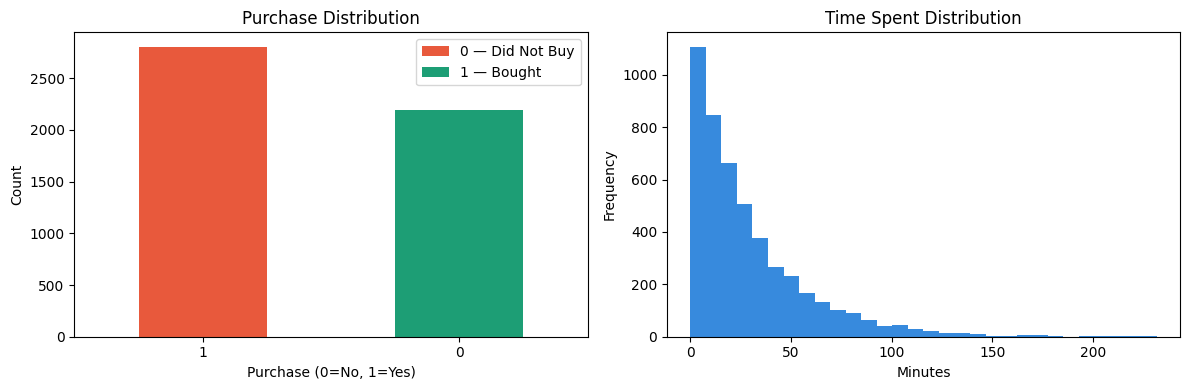

Purchase rate: 56.06%


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df['purchase'].value_counts().plot(
    kind = 'bar',
    ax= axes[0],
    color=['#E8593c' ,'#1D9E75']
    
)

axes[0].set_title('Purchase Distribution')
axes[0].set_xlabel('Purchase (0=No, 1=Yes)')
axes[0].set_ylabel('Count')
axes[0].tick_params(rotation=0)
legend_elements = [
    Patch(facecolor='#E8593C', label='0 — Did Not Buy'),
    Patch(facecolor='#1D9E75', label='1 — Bought')
]
axes[0].legend(handles=legend_elements)


#------------------------------

df['time_spent'].dropna().plot(
    kind='hist',
    ax=axes[1],
    bins=30,
    color='#378ADD'
)
axes[1].set_title('Time Spent Distribution')
axes[1].set_xlabel('Minutes')


plt.tight_layout()
plt.show()

print(f"Purchase rate: {df['purchase'].mean():.2%}")